# 15

In [1]:
import pandas as pd
from pathlib import Path
import os

current_dir = Path.cwd()
data_path = os.path.join(current_dir, "sampled_reviews.csv")

print("current_dir:", current_dir)
print("data_path:", data_path)

current_dir: C:\Users\Administrator\Desktop
data_path: C:\Users\Administrator\Desktop\sampled_reviews.csv


In [2]:
#load data

df = pd.read_csv(data_path)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   overall                  2000 non-null   int64  
 1   verified                 2000 non-null   bool   
 2   reviewTime               2000 non-null   object 
 3   reviewerID               2000 non-null   object 
 4   asin                     2000 non-null   object 
 5   reviewerName             2000 non-null   object 
 6   reviewText               2000 non-null   object 
 7   summary                  2000 non-null   object 
 8   unixReviewTime           2000 non-null   int64  
 9   vote                     178 non-null    float64
 10  style                    794 non-null    object 
 11  image                    23 non-null     object 
 12  reviewText_length_words  2000 non-null   int64  
 13  summary_length_words     2000 non-null   int64  
 14  label                   

In [4]:
df.head(5)

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,reviewText_length_words,summary_length_words,label
0,5,True,"08 18, 2015",A15ZDMON8G1OI5,B00DCGWYKI,Art Rodriguez,Fast delivery and effective. Exactly what I wa...,Five Stars,1439856000,NaN,NaN,NaN,10,2,POSITIVE
1,1,True,"08 19, 2016",A1RSNXJADULT5R,B01EJMLO8G,H C,Operator manual confusing. Refers to wire feed...,Poor product. Won't buy this again.,1471564800,15.0,NaN,NaN,49,6,NEGATIVE
2,1,True,"05 7, 2014",A1O8JACMOU1ZO1,B002PJEXEI,Matthew Hitzges,This stethoscope does not work properly. I re...,Do Not Buy!,1399420800,NaN,NaN,NaN,20,3,NEGATIVE
3,5,True,"01 10, 2014",A1A1L113H9YOFS,B0058QKFBU,George H.,I believe this is more than enough gaffer tape...,perfect rolls for travel!,1389312000,NaN,NaN,NaN,31,4,POSITIVE
4,5,True,"09 16, 2013",A3UKWDXIOOEZH7,B0050CFIQY,Samantha,if you ever seen a 3 oz. bath and body works l...,There not as big as the picture,1379289600,NaN,{'Size:': ' Single Pack'},NaN,36,7,POSITIVE


In [5]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob
from sklearn.preprocessing import LabelEncoder


df["text"] = df["summary"] + " " + df["reviewText"]

df["user_item"] = df["reviewerID"] + "_" + df["asin"]

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["user_id"] = user_encoder.fit_transform(df["reviewerID"])
df["item_id"] = item_encoder.fit_transform(df["asin"])

In [6]:
# Sentiment score
df["sentiment"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)


In [7]:
# TF-IDF similarity
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["text"])
tfidf_sim = cosine_similarity(tfidf_matrix)


In [8]:
# Hybrid similarity
hybrid_sim = tfidf_sim

def hybrid_score(index, top_n=5):
    scores = list(enumerate(hybrid_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [i for i, _ in scores]
    avg_rating = df.iloc[indices]["overall"].mean()
    avg_sentiment = df.iloc[indices]["sentiment"].mean()
    return 0.6 * avg_rating + 0.4 * (avg_sentiment * 5)

df["enhanced_rating"] = [
    0.5 * df.iloc[i]["overall"] + 0.5 * hybrid_score(i)
    for i in range(len(df))
]

df[["summary", "reviewText", "overall", "sentiment", "enhanced_rating"]].to_csv("enhanced_output_advanced.csv", index=False)

def recommend_items(index, top_n=5):
    scores = list(enumerate(hybrid_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [i for i, _ in scores]
    recommendations = df.iloc[indices][["summary", "reviewText", "overall", "enhanced_rating"]]
    print(f"Top {top_n} recommendations for item {index}:")
    for i, row in recommendations.iterrows():
        print(f"\n--- Recommendation {i} ---")
        print(f"Summary: {row['summary']}")
        print(f"Review: {row['reviewText']}")
        print(f"Enhanced Rating: {row['enhanced_rating']:.2f}")

recommend_items(0)

Top 5 recommendations for item 0:

--- Recommendation 1414 ---
Summary: Five Stars
Review: Exactly what I wanted
Enhanced Rating: 4.15

--- Recommendation 993 ---
Summary: Five Stars
Review: great product and fast delivery
Enhanced Rating: 4.52

--- Recommendation 341 ---
Summary: Five Stars
Review: great price for it, fast delivery
Enhanced Rating: 4.52

--- Recommendation 265 ---
Summary: Five Stars
Review: Bags were great!  Delivery was fast!
Enhanced Rating: 4.51

--- Recommendation 1777 ---
Summary: Five Stars
Review: Exactly what I was looking for. Thank you
Enhanced Rating: 4.11


In [9]:
def generate_html_recommendations(index, top_n=5, output_file="recommendations.html"):
    scores = list(enumerate(hybrid_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [i for i, _ in scores]
    recommendations = df.iloc[indices][["summary", "reviewText", "overall", "enhanced_rating"]]
    
    html = f"""
    <html>
    <head>
        <title>Top {top_n} Recommendations for Item {index}</title>
        <style>
            body {{ font-family: Arial, sans-serif; padding: 20px; }}
            .rec {{ border: 1px solid #ddd; padding: 15px; margin-bottom: 10px; border-radius: 8px; }}
            .rating {{ color: #f39c12; font-weight: bold; }}
        </style>
    </head>
    <body>
        <h1>Top {top_n} Recommendations for Item {index}</h1>
    """

    for _, row in recommendations.iterrows():
        html += f"""
        <div class="rec">
            <h2>{row['summary']}</h2>
            <p>{row['reviewText']}</p>
            <p class="rating">Original Rating: {row['overall']:.2f}</p>
            <p class="rating">Enhanced Rating: {row['enhanced_rating']:.2f}</p>
        </div>
        """

    html += "</body></html>"

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(html)
    print(f"Recommendations saved to {output_file}")

generate_html_recommendations(0)

Recommendations saved to recommendations.html


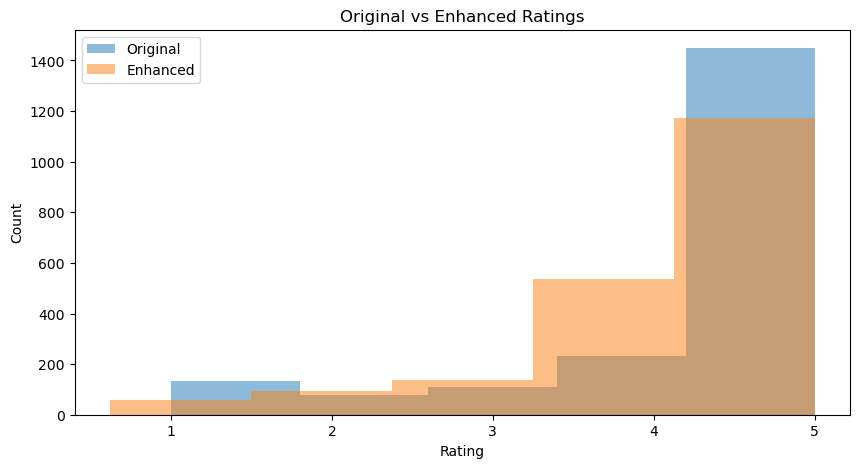

In [10]:
import matplotlib.pyplot as plt  

plt.figure(figsize=(10, 5))
plt.hist(df['overall'], bins=5, alpha=0.5, label='Original')
plt.hist(df['enhanced_rating'], bins=5, alpha=0.5, label='Enhanced')
plt.title('Original vs Enhanced Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend()
plt.show()